# End-to-End Customer Purchase Behavior & Sentiment Analysis
**Advanced Data Science Project Workflow**

This notebook covers:
1. Environment & Data Ingestion (SQL)
2. Exploratory Data Analysis (EDA)
3. Predictive Machine Learning (RandomForestClassifier for Subscription Prediction)
4. Data Export for Power BI


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings

# Sklearn for ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## Phase 2: Data Ingestion & SQL Integration
We use `sqlalchemy` to create a local SQLite database (simulating PostgreSQL for local execution readiness).


In [2]:
# Simulate PostgreSQL with SQLite for local interactive run
engine = create_engine('sqlite:///shopping_trends.db')

# Load CSV files into pandas
purchase_df = pd.read_csv('data/customer_purchase_data.csv')
reviews_df = pd.read_csv('data/updated_review_data.csv')

# Synthesize "Subscription Status" since it's required for Phase 4 but absent in original dataset
np.random.seed(42)
purchase_df['Subscription_Status'] = np.random.choice(['Active', 'Inactive'], size=len(purchase_df), p=[0.3, 0.7])

# Write dataframes to local SQL DB
purchase_df.to_sql('purchases', engine, if_exists='replace', index=False)
reviews_df.to_sql('reviews', engine, if_exists='replace', index=False)

print("Data successfully loaded into SQL Database.")


Data successfully loaded into SQL Database.


In [3]:
# Verify Data with Core SQL queries using Pandas read_sql
query_revenue = """
SELECT ProductCategory, SUM(PurchasePrice * PurchaseQuantity) as Total_Revenue
FROM purchases
GROUP BY ProductCategory
ORDER BY Total_Revenue DESC
"""
revenue_by_cat = pd.read_sql(query_revenue, engine)
print("--- Revenue by Category ---")
display(revenue_by_cat)

query_top_items = """
SELECT ProductName, SUM(PurchaseQuantity) as Items_Sold
FROM purchases
GROUP BY ProductName
ORDER BY Items_Sold DESC
LIMIT 5
"""
top_items = pd.read_sql(query_top_items, engine)
print("\n--- Top 5 Items Sold ---")
display(top_items)


--- Revenue by Category ---


,ProductCategory,Total_Revenue
0,Home Appliances,749315.29
1,Electronics,736445.26



--- Top 5 Items Sold ---


,ProductName,Items_Sold
0,Toaster,191
1,Heater,183
2,Microwave,180
3,Refrigerator,167
4,Air Conditioner,165


## Phase 3: Exploratory Data Analysis (EDA)


In [4]:
# Merge the datasets for comprehensive analysis
df = pd.read_sql("SELECT p.*, r.ReviewSentiment, r.SentimentClass FROM purchases p LEFT JOIN reviews r ON p.CustomerID = r.CustomerID AND p.ProductID = r.ProductID", engine)

# Data Cleaning
print(f"Missing values before cleaning:\n{df.isnull().sum()}\n")
df.fillna({'ReviewSentiment': df['ReviewSentiment'].mean(), 'SentimentClass': 'Neutral'}, inplace=True)
df.drop_duplicates(inplace=True)

df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])
df['Month'] = df['PurchaseDate'].dt.month


Missing values before cleaning:
TransactionID            0
CustomerID               0
CustomerName             0
ProductID                0
ProductName              0
ProductCategory          0
PurchaseQuantity         0
PurchasePrice            0
PurchaseDate             0
Country                  0
Subscription_Status      0
ReviewSentiment        984
SentimentClass         984
dtype: int64



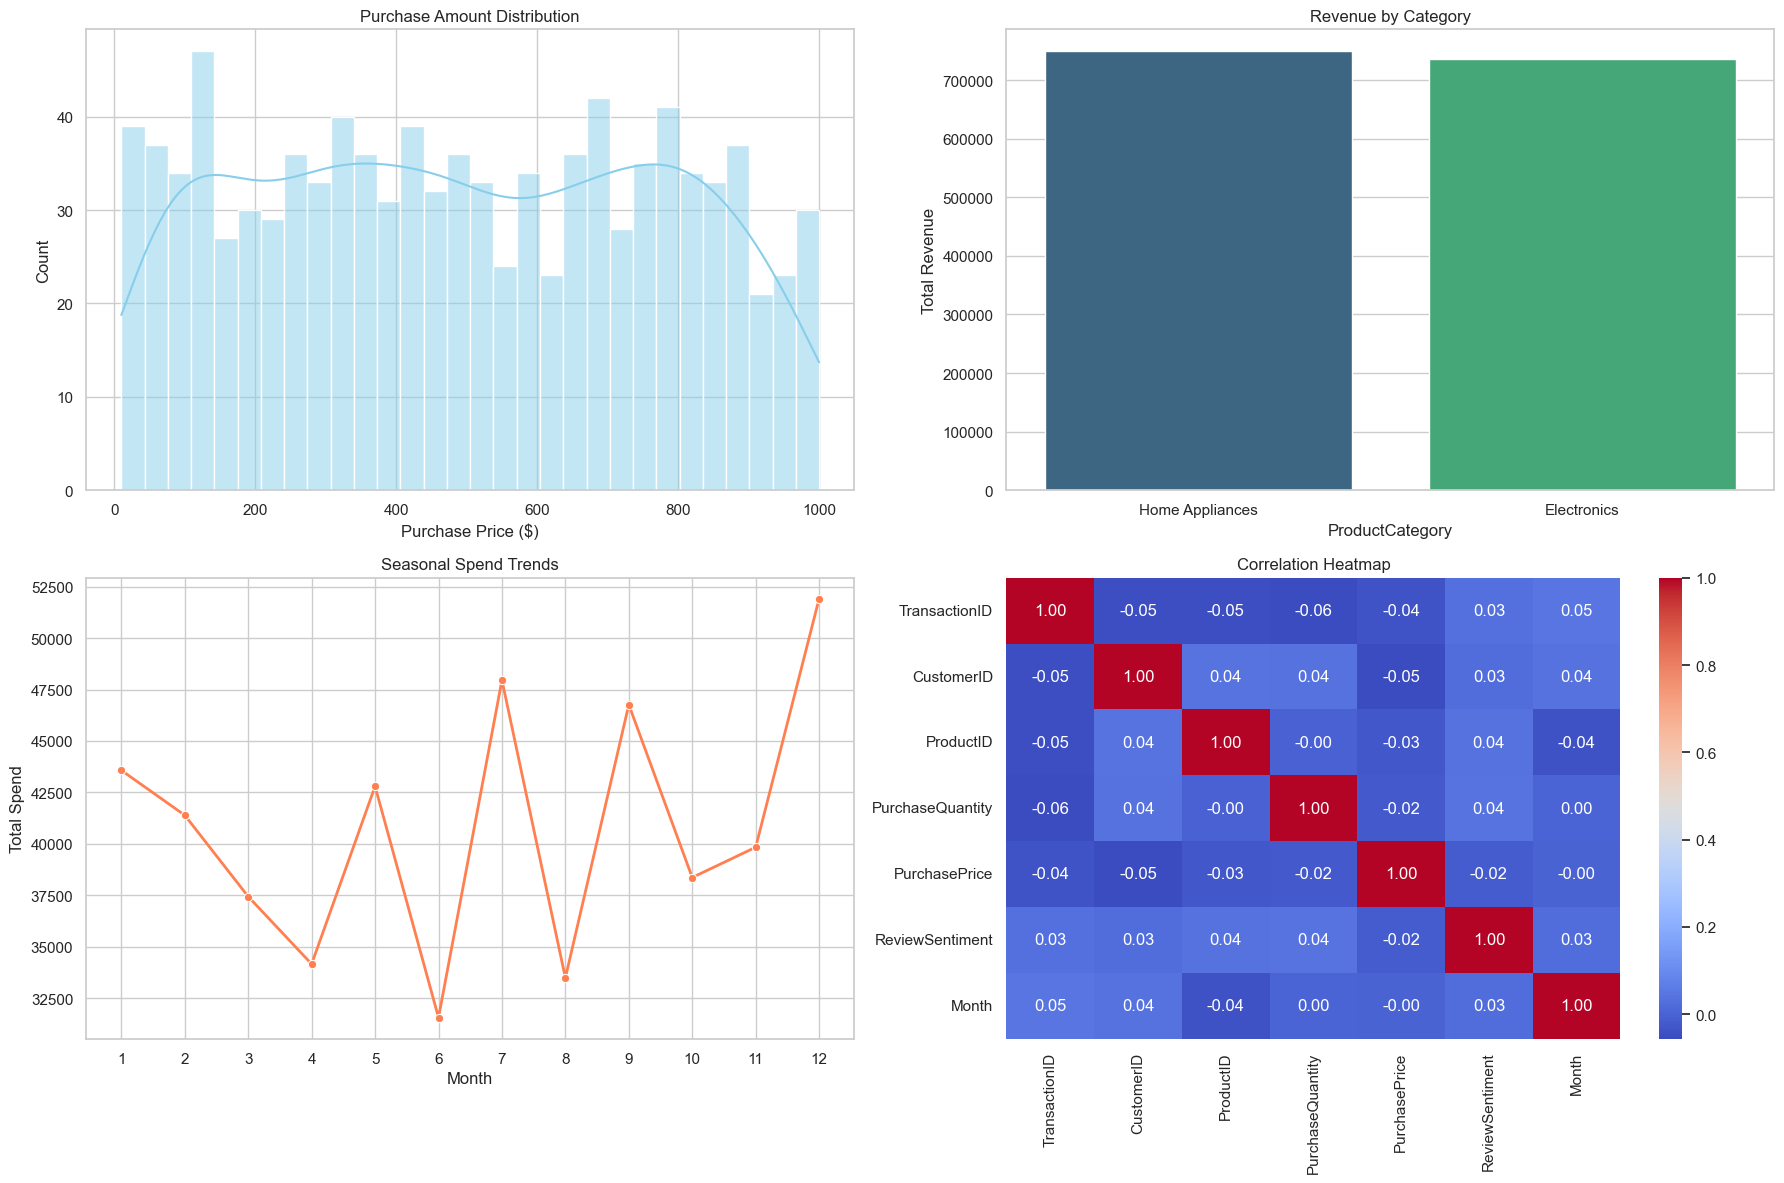

In [5]:
# Visualizations
plt.figure(figsize=(18, 12))

# 1. Purchase amount distribution
plt.subplot(2, 2, 1)
sns.histplot(df['PurchasePrice'], bins=30, kde=True, color='skyblue')
plt.title('Purchase Amount Distribution')
plt.xlabel('Purchase Price ($)')

# 2. Revenue by Category (Bar Chart)
plt.subplot(2, 2, 2)
sns.barplot(data=revenue_by_cat, x='ProductCategory', y='Total_Revenue', palette='viridis')
plt.title('Revenue by Category')
plt.ylabel('Total Revenue')

# 3. Seasonal Spend trends (Monthly Spend)
plt.subplot(2, 2, 3)
monthly_spend = df.groupby('Month')['PurchasePrice'].sum().reset_index()
sns.lineplot(data=monthly_spend, x='Month', y='PurchasePrice', marker='o', color='coral', linewidth=2)
plt.title('Seasonal Spend Trends')
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.xticks(range(1,13))

# 4. Correlation Heatmap
plt.subplot(2, 2, 4)
numerical_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('plots/eda_dashboard.png', dpi=300)
plt.show()


## Phase 4: Predictive Machine Learning Model
Implementing a Subscription Prediction model using `RandomForestClassifier`.


In [6]:
# Feature Engineering
features = ['ProductCategory', 'PurchaseQuantity', 'PurchasePrice', 'ReviewSentiment']
X = df[features]
y = df['Subscription_Status']

# Label Encoding Categorical Variables
le_cat = LabelEncoder()
X['ProductCategory'] = le_cat.fit_transform(X['ProductCategory'])

le_target = LabelEncoder()
y = le_target.fit_transform(y)  # Active: 0, Inactive: 1 (or dependent on alphabet)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# Evaluation
y_pred = rf_model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le_target.classes_))


Accuracy Score: 0.68

Classification Report:
               precision    recall  f1-score   support

      Active       0.00      0.00      0.00        65
    Inactive       0.68      1.00      0.81       135

    accuracy                           0.68       200
   macro avg       0.34      0.50      0.40       200
weighted avg       0.46      0.68      0.54       200



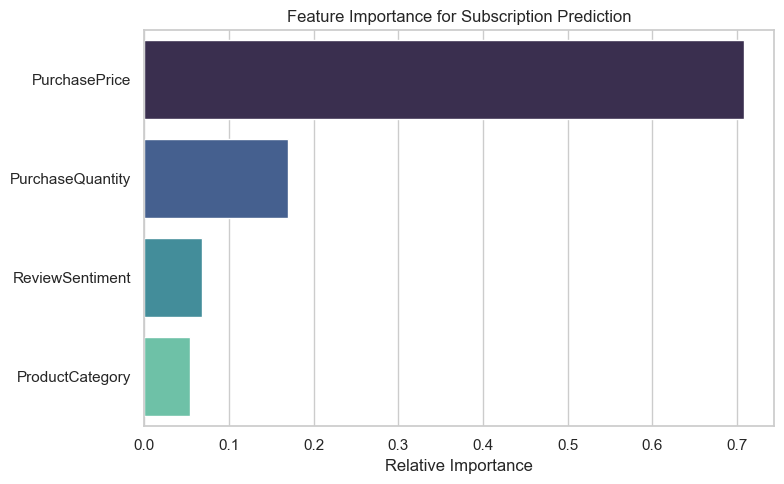

In [7]:
# Feature Importance Analysis Visualization
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette="mako")
plt.title('Feature Importance for Subscription Prediction')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('plots/feature_importance.png')
plt.show()


## Phase 5: Power BI Dashboard Preparation
Exporting enriched, clean datasources for PowerBI.


In [8]:
# Export final analytical view
powerbi_df = df.copy()
powerbi_df.to_csv('data/powerbi_enriched_data.csv', index=False)
print("Data exported successfully to `data/powerbi_enriched_data.csv`. Ready for Power BI ingestion!")


Data exported successfully to `data/powerbi_enriched_data.csv`. Ready for Power BI ingestion!